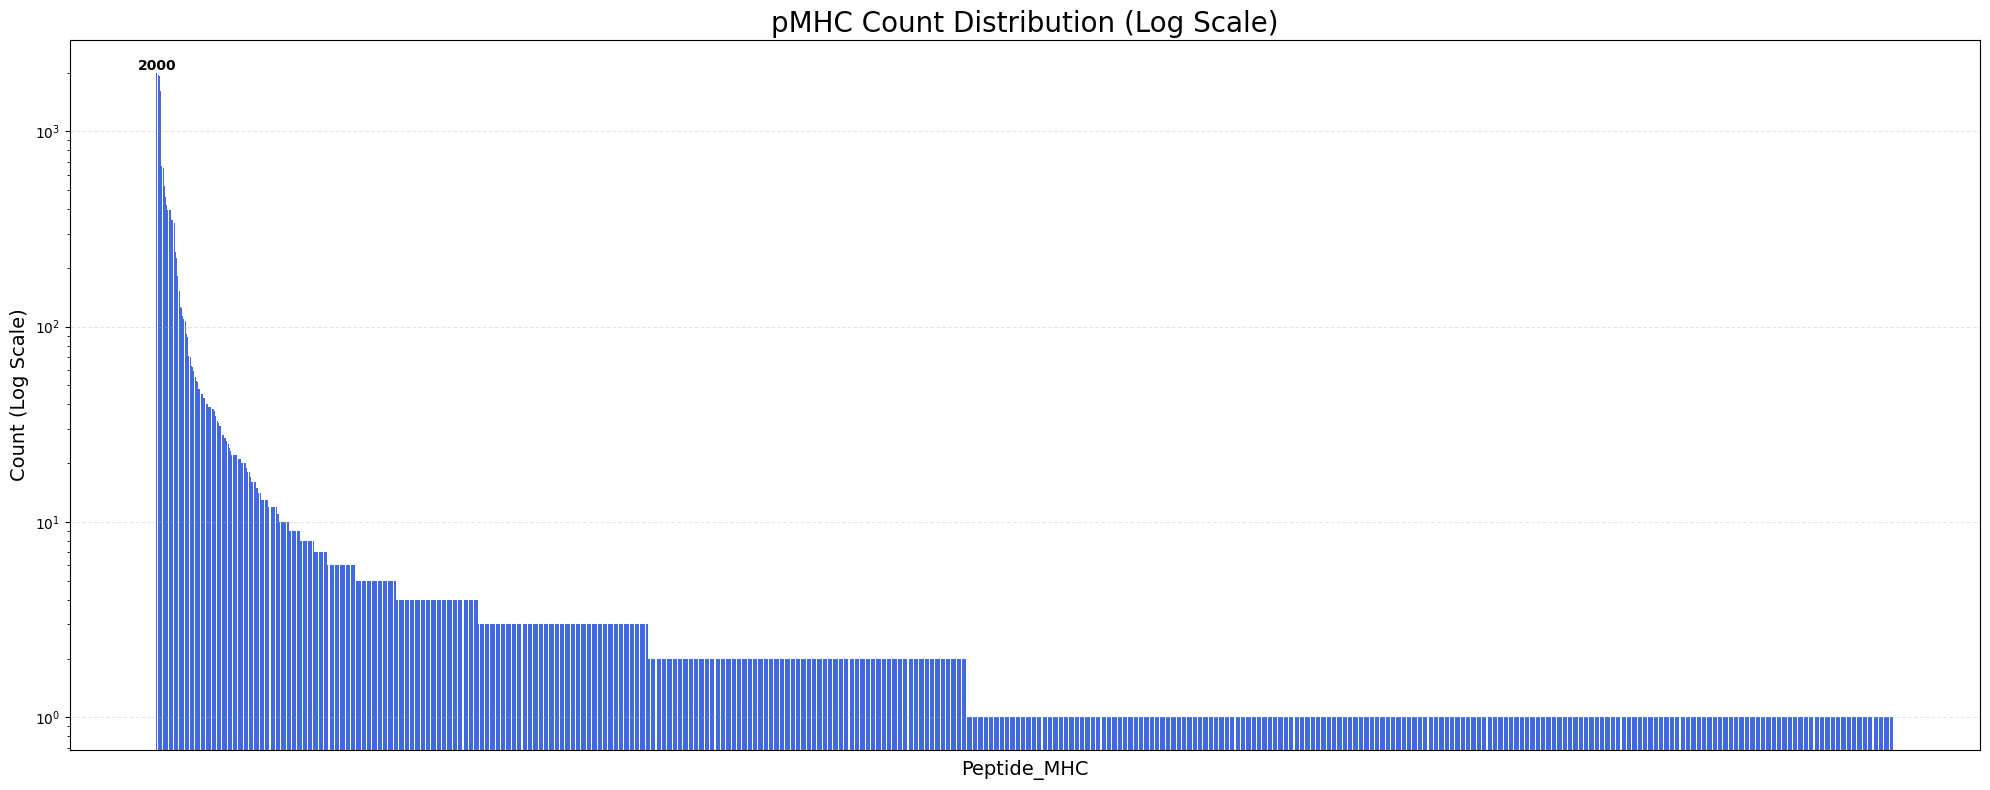

In [1]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

# 1. 데이터 로드
with open('sorted_dictionary.pkl', 'rb') as f:
    loaded_data = pickle.load(f)

# 2. 데이터 정렬
sorted_items = sorted(loaded_data.items(), key=lambda item: item[1], reverse=True)
peptides = [item[0] for item in sorted_items]
counts = [item[1] for item in sorted_items]

# 3. Bar Plot 그리기
plt.figure(figsize=(20, 8))

# 막대 그래프 생성
plt.bar(peptides, counts, color='royalblue', log=True)

# 그래프 꾸미기
plt.title('pMHC Count Distribution (Log Scale)', fontsize=20)
plt.xlabel('Peptide_MHC', fontsize=14)
plt.ylabel('Count (Log Scale)', fontsize=14)

plt.xticks([]) 
plt.grid(axis='y', alpha=0.3, linestyle='--')

# 상위 3개 값 텍스트 표시
for i in range(min(1, len(counts))):
    plt.text(i, counts[i], f'{counts[i]}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('figure_data_dist.png')
plt.show() # 확인용

In [2]:
#print(loaded_data)

In [3]:
with open('peps.pkl', 'rb') as f:
    peps = pickle.load(f)
with open('mhcs.pkl', 'rb') as f:
    mhcs = pickle.load(f)

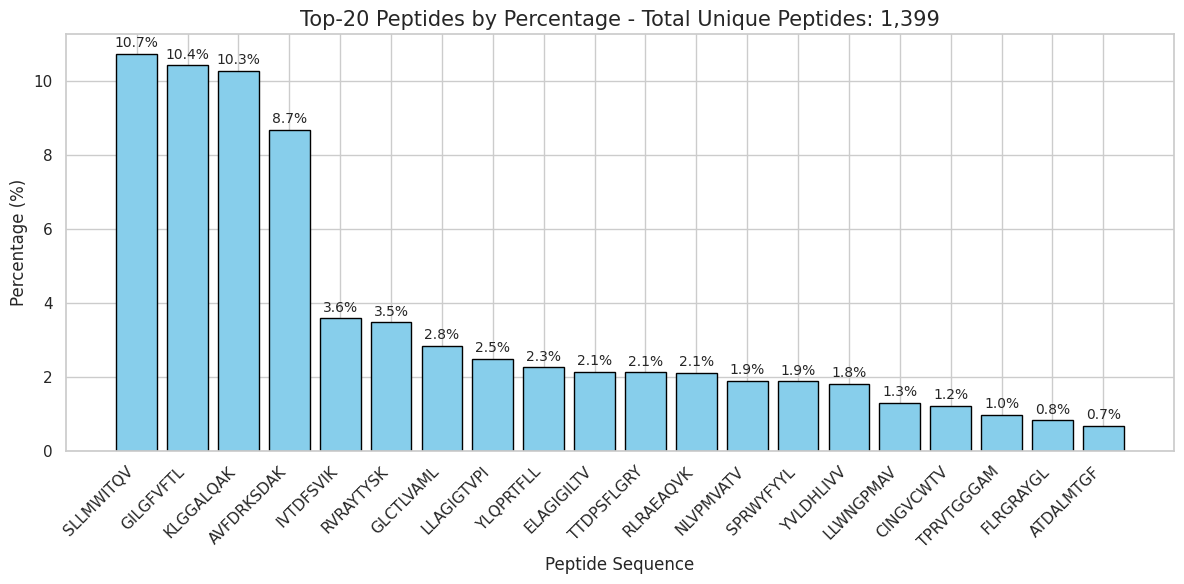

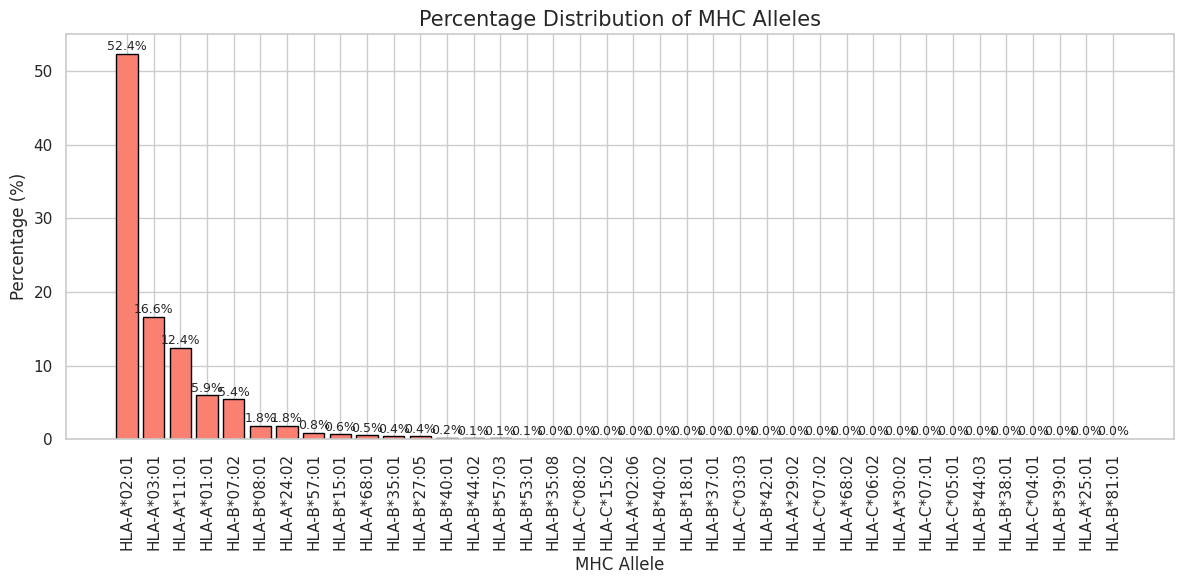

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Set a nice style for the plots
sns.set_theme(style="whitegrid")

def visualize_data(peptides_list, mhc_list, k=15):
    """
    Visualizes top-k peptides and MHC distribution.
    
    Args:
        peptides_list (list): List of all peptides (with duplicates).
        mhc_list (list): List of all MHCs (with duplicates).
        k (int): Number of top peptides to display.
    """
    total_count = len(peptides_list)
    
    # --- 1. Top-k Peptides Visualization ---
    # Count frequencies
    pep_counts = Counter(peptides_list)
    # Get top k
    top_k_data = pep_counts.most_common(k)
    
    pep_labels = [item[0] for item in top_k_data]
    pep_values = [item[1] for item in top_k_data]
    # Calculate percentages
    pep_percentages = [(val / total_count) * 100 for val in pep_values]

    plt.figure(figsize=(12, 6))
    # Create bar plot
    bars = plt.bar(pep_labels, pep_percentages, color='skyblue', edgecolor='black')
    
    unique_count = len(list(set(peptides_list)))
    
    plt.title(f'Top-{k} Peptides by Percentage - Total Unique Peptides: {unique_count:,}', fontsize=15)
    plt.ylabel('Percentage (%)', fontsize=12)
    plt.xlabel('Peptide Sequence', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    
    # Add percentage labels on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                 f'{height:.1f}%', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('figure_pep_dist.png')

    # --- 2. MHC Distribution Visualization ---
    # Count frequencies
    mhc_counts = Counter(mhc_list)
    # Sort by count (descending)
    sorted_mhc_data = mhc_counts.most_common()
    
    mhc_labels = [item[0] for item in sorted_mhc_data]
    mhc_values = [item[1] for item in sorted_mhc_data]
    mhc_percentages = [(val / total_count) * 100 for val in mhc_values]

    plt.figure(figsize=(12, 6))
    # Create bar plot
    bars_mhc = plt.bar(mhc_labels, mhc_percentages, color='salmon', edgecolor='black')
    
    plt.title('Percentage Distribution of MHC Alleles', fontsize=15)
    plt.ylabel('Percentage (%)', fontsize=12)
    plt.xlabel('MHC Allele', fontsize=12)
    plt.xticks(rotation=90) # Rotate 90 degrees if many alleles
    
    # Add percentage labels
    for bar in bars_mhc:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                 f'{height:.1f}%', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('figure_mhc_dist.png')

# --- Call the function with your data ---
# 'peps' and 'mhcs' are the lists populated in your previous loop
if len(peps) > 0:
    visualize_data(peps, mhcs, k=20)
else:
    print("No data available to visualize.")